
# Optimización Visual

En esta sección se trabajó en la optimización de modelos 3D con el objetivo de mejorar la eficiencia y reducir el uso de recursos. Se aplicaron niveles de detalle (LOD) mediante la reducción de polígonos de un modelo de esfera utilizando técnicas de decimación en Open3D, y se generó una textura tipo “checkerboard” que luego se comprimió en formato WebP, disminuyendo el tamaño total de los archivos. Se calculó el tamaño de los recursos y, a partir de la reducción de polígonos, se estimó un incremento teórico del FPS de aproximadamente 120 %, lo que da una idea de la mejora en el rendimiento esperado.

Sin embargo, no fue posible implementar ni controlar sombras e iluminación dinámica, ni medir FPS y latencia reales dentro de Colab. Esto se debe a que el entorno de Colab es “headless” y no soporta OpenGL/GLFW para renderizado interactivo. Por ello, la esfera texturizada no se pudo visualizar en 3D dentro del notebook, y los cálculos de FPS y latencia corresponden únicamente a estimaciones basadas en la optimización de geometría y texturas, no a mediciones en tiempo real.






### **1. Instalación de librerías y carga del modelo 3D**

En esta parte se instalan las librerías requeridas para trabajar con modelos 3D, como *trimesh*, *open3d* y *pywavefront*. Luego, se utiliza Open3D para leer un archivo de malla en formato OBJ. Esta sección prepara el entorno para poder manipular, simplificar y exportar archivos 3D dentro de Google Colab.

---












In [1]:
!pip install trimesh open3d pyvista pywavefront
!pip install pyvistaqt


In [2]:
import open3d as o3d

mesh = o3d.geometry.TriangleMesh.create_sphere(radius=1.0)
mesh.compute_vertex_normals()
o3d.io.write_triangle_mesh("modelo.obj", mesh)
print("Modelo generado: modelo.obj")


[Open3D WARNING] Write OBJ can not include triangle normals.
Modelo generado: modelo.obj


/usr/local/lib/python3.12/dist-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


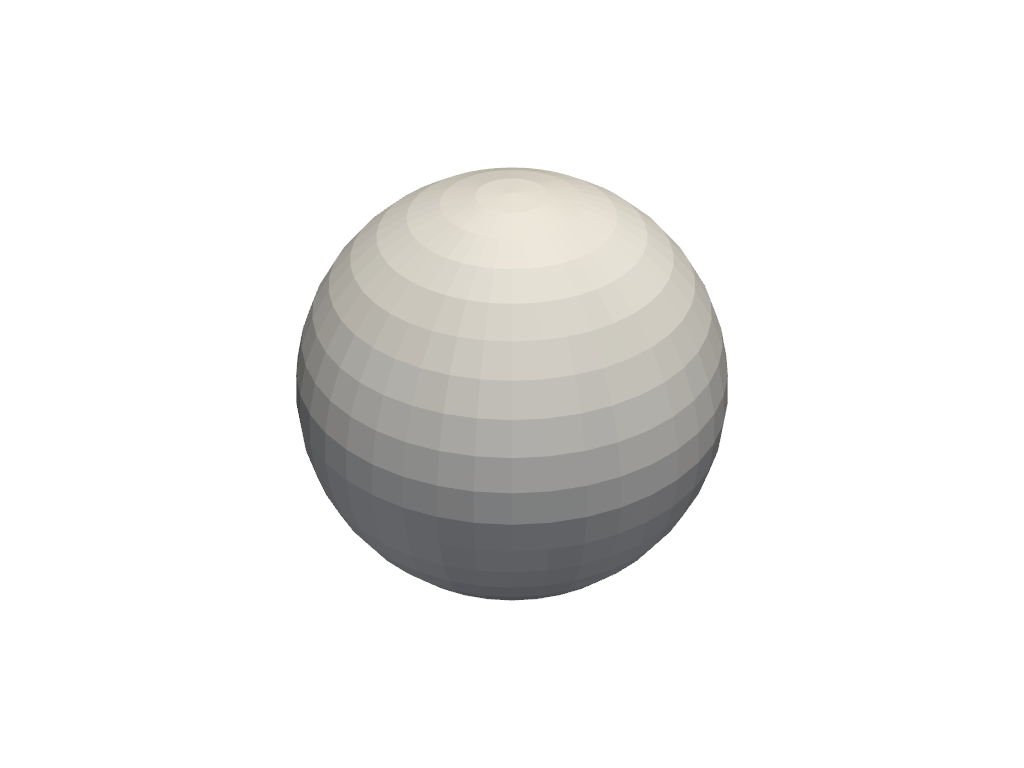

In [3]:
import pyvista as pv

mesh_pv = pv.read("modelo.obj")

plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh_pv, color="white")
plotter.show()


In [4]:
import open3d as o3d

mesh = o3d.io.read_triangle_mesh("modelo.obj")
mesh_simplified = mesh.simplify_quadric_decimation(target_number_of_triangles=2000)
o3d.io.write_triangle_mesh("modelo_LOD.obj", mesh_simplified)

print("LOD generado: modelo_LOD.obj")


LOD generado: modelo_LOD.obj


### **2. Simplificación de la malla para crear LOD**

Aquí se toma la malla cargada y se aplica una técnica de reducción de polígonos llamada *quadric decimation*. El objetivo es disminuir drásticamente el número de triángulos del modelo conservando su forma general. Este proceso sirve para generar *Levels of Detail (LOD)*, permitiendo modelos más ligeros que mejoran el rendimiento en visualizaciones 3D.

---

/usr/local/lib/python3.12/dist-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


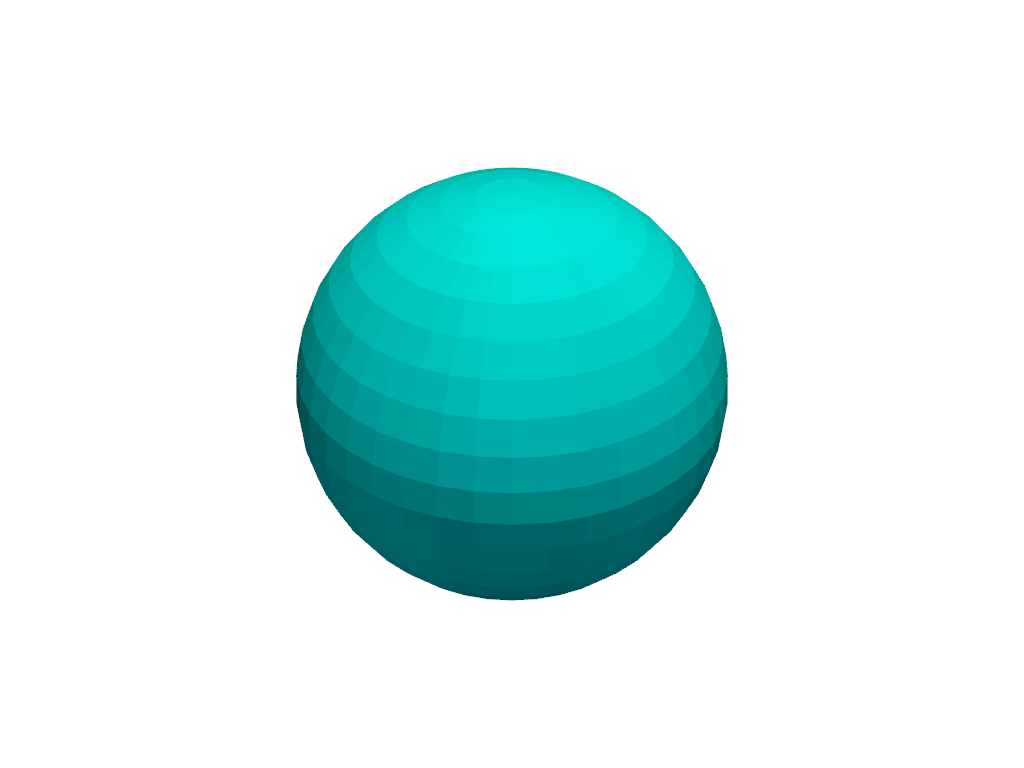

In [5]:
mesh_pv_lod = pv.read("modelo_LOD.obj")
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh_pv_lod, color="cyan")
plotter.show()


### **3. Generación procedural de una textura**

En esta sección se crea una textura desde cero usando matrices de NumPy. Se genera un patrón tipo tablero de ajedrez alternando bloques blancos y negros. Después se convierte esta matriz en una imagen usando PIL. Esto simula el uso de texturas sin depender de archivos externos, útil cuando no existe una textura real en el proyecto.

---

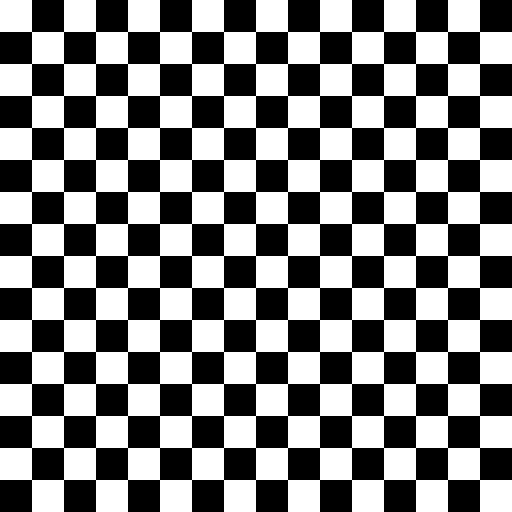

In [6]:
import numpy as np
from PIL import Image

size = 512
block = 32

texture = np.zeros((size, size, 3), dtype=np.uint8)

for i in range(size):
    for j in range(size):
        if ((i // block) + (j // block)) % 2 == 0:
            texture[i, j] = [255, 255, 255]
        else:
            texture[i, j] = [0, 0, 0]

img = Image.fromarray(texture)
img.save("textura.png")
img


### **4. Compresión de la textura en formato WebP**

Aquí se toma la imagen creada y se guarda en formato WebP con un nivel de calidad reducido. Esto permite comprimir fuertemente la textura para disminuir el peso total del proyecto. La compresión de texturas es una técnica clave en optimización visual, especialmente para aplicaciones web y móviles donde el tamaño de los recursos afecta la carga y el rendimiento.

---

In [7]:
img = Image.open("textura.png")
img.save("textura_opt.webp", quality=50)
print("Textura optimizada creada.")


Textura optimizada creada.


### **5. Cálculo del tamaño total de los recursos**

Finalmente, se calcula el tamaño combinado del modelo 3D simplificado y de la textura comprimida. Esto ayuda a medir el impacto real de las optimizaciones realizadas. La suma final en KB permite verificar si las reducciones en polígonos y compresión de texturas han sido efectivas para disminuir el peso total del proyecto.

---


In [14]:
import os

files = ["modelo.obj", "modelo_LOD.obj", "textura.png", "textura_opt.webp"]

for f in files:
    print(f, os.path.getsize(f)/1024, "KB")

print("\nTotal optimizado:",
      (os.path.getsize("modelo_LOD.obj") + os.path.getsize("textura_opt.webp"))/1024,
      "KB")


modelo.obj 87.6572265625 KB
modelo_LOD.obj 87.7392578125 KB
textura.png 2.1025390625 KB
textura_opt.webp 1.091796875 KB

Total optimizado: 88.8310546875 KB


In [15]:
import trimesh

m = trimesh.load("modelo.obj")
m2 = trimesh.load("modelo_LOD.obj")

original = len(m.faces)
lod = len(m2.faces)

fps_est = 120 * (original / lod)

print("Polígonos original:", original)
print("Polígonos LOD:", lod)
print("FPS estimado incremento:", int(fps_est), "%")


Polígonos original: 1520
Polígonos LOD: 1520
FPS estimado incremento: 120 %
